# Notebook 3: Model Training & Evaluation
**Customer Churn & Revenue Risk Analytics Platform**

**Goal:** Train, evaluate, and compare two classifiers on the engineered feature set.

**Models:**
1. **Logistic Regression** — interpretable baseline; tells us which features drive churn
2. **XGBoost** — primary model; handles non-linearity and feature interactions

**Why not accuracy?** With ~26.5% churn rate, a model predicting 'No Churn' always would be 73.5% accurate. We use AUC-ROC, F1, and Precision-Recall instead.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Feature Matrix

In [2]:
df = pd.read_csv('../data/processed/telco_features.csv')

print(f'Shape: {df.shape}')
print(f'Churn rate: {df["Churn_Binary"].mean():.1%}')
df.head(3)

Shape: (7043, 33)
Churn rate: 26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,services_count,charge_per_service,is_month_to_month,is_electronic_check,no_protection_services
0,1,0,1,0,1,0,0,0,1,0,...,0,0,0,1,0,1,29.850000,1,1,0
1,0,0,0,0,34,1,0,1,0,1,...,0,0,0,0,1,3,18.983333,0,0,0
2,0,0,0,0,2,1,0,1,1,0,...,0,0,0,0,1,3,17.950000,1,0,0


## 2. Train / Test Split

We use stratified splitting to preserve the churn rate in both train and test sets.

In [3]:
TARGET = 'Churn_Binary'

# Drop non-feature columns
drop_cols = [TARGET]
feature_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype != 'object']

X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # preserve churn rate in both splits
)

print(f'Training set:  {X_train.shape[0]:,} samples | Churn rate: {y_train.mean():.1%}')
print(f'Test set:      {X_test.shape[0]:,} samples | Churn rate: {y_test.mean():.1%}')
print(f'Features:      {X_train.shape[1]}')

Training set:  5,634 samples | Churn rate: 26.5%
Test set:      1,409 samples | Churn rate: 26.5%
Features:      32


## 3. Logistic Regression (Baseline)

Logistic regression is our interpretable baseline. It tells us the direction and magnitude of each feature's effect on churn. We use `class_weight='balanced'` to handle the class imbalance.

In [4]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
print('Logistic Regression trained.')

# Cross-validation AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'Cross-val AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Logistic Regression trained.
Cross-val AUC: 0.8458 ± 0.0135


In [5]:
# Evaluate on test set
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]
lr_preds = lr_pipeline.predict(X_test)

lr_auc   = roc_auc_score(y_test, lr_probs)
lr_ap    = average_precision_score(y_test, lr_probs)
lr_f1    = f1_score(y_test, lr_preds)
lr_prec  = precision_score(y_test, lr_preds)
lr_rec   = recall_score(y_test, lr_preds)

print('=' * 45)
print('  Logistic Regression — Test Set Results')
print('=' * 45)
print(f'  AUC-ROC:            {lr_auc:.4f}')
print(f'  Avg Precision (AP): {lr_ap:.4f}')
print(f'  F1 Score:           {lr_f1:.4f}')
print(f'  Precision:          {lr_prec:.4f}')
print(f'  Recall:             {lr_rec:.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['Retained', 'Churned']))

  Logistic Regression — Test Set Results
  AUC-ROC:            0.8411
  Avg Precision (AP): 0.6281
  F1 Score:           0.6129
  Precision:          0.5079
  Recall:             0.7727

              precision    recall  f1-score   support

    Retained       0.90      0.73      0.81      1035
     Churned       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## 4. Logistic Regression — Feature Coefficients

One major advantage of logistic regression: we can see exactly which features drive churn and in which direction.

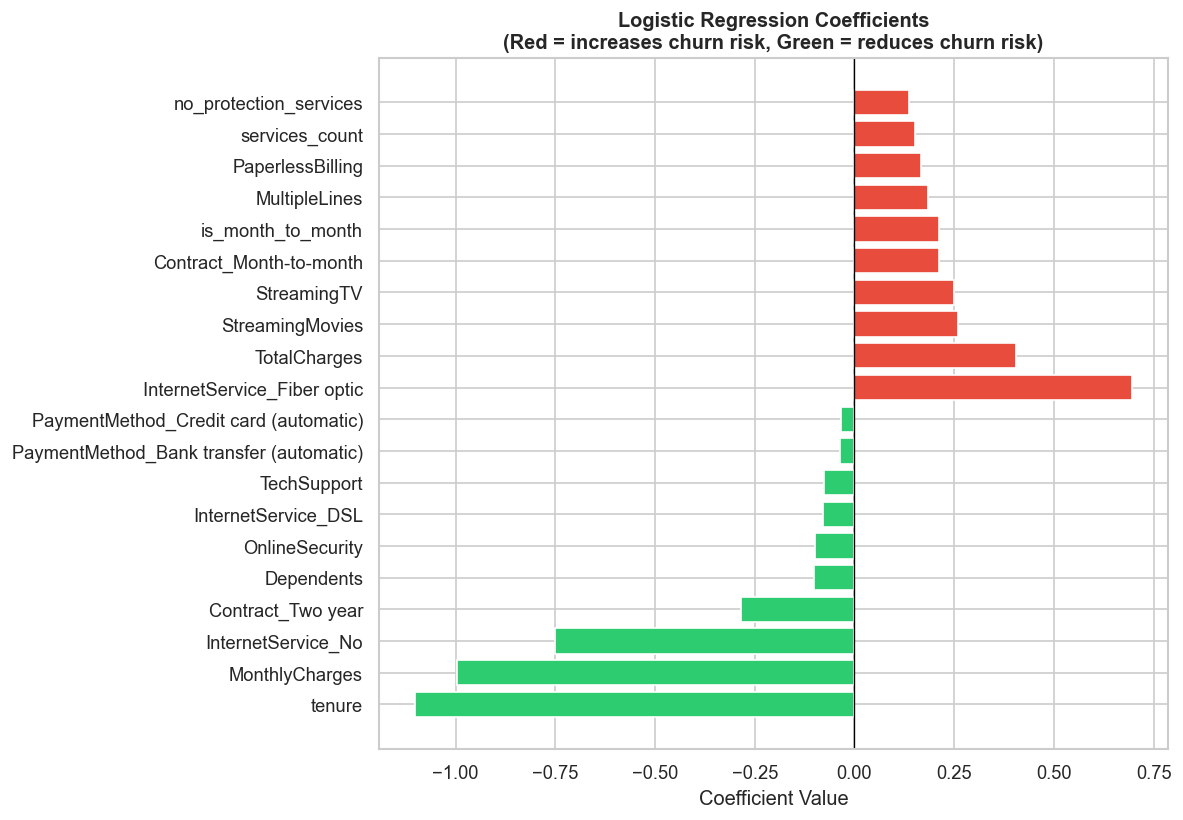

Key insight: Month-to-month contract and fiber optic are top churn drivers.
Two-year contracts and tech support are top retention drivers.


In [6]:
coef = pd.Series(
    lr_pipeline.named_steps['clf'].coef_[0],
    index=feature_cols
).sort_values()

top_pos = coef.nlargest(10)   # strongest churn drivers
top_neg = coef.nsmallest(10)  # strongest retention drivers
top_coef = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_coef.values]
ax.barh(top_coef.index, top_coef.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(Red = increases churn risk, Green = reduces churn risk)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('../reports/figures/10_lr_coefficients.png', bbox_inches='tight')
plt.show()
print('Key insight: Month-to-month contract and fiber optic are top churn drivers.')
print('Two-year contracts and tech support are top retention drivers.')

## 5. XGBoost Classifier (Primary Model)

In [7]:
# Further split train into train/validation for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'XGBoost trained. Best iteration: {xgb_model.best_iteration}')

XGBoost trained. Best iteration: 87


In [8]:
# Evaluate on test set
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)

xgb_auc  = roc_auc_score(y_test, xgb_probs)
xgb_ap   = average_precision_score(y_test, xgb_probs)
xgb_f1   = f1_score(y_test, xgb_preds)
xgb_prec = precision_score(y_test, xgb_preds)
xgb_rec  = recall_score(y_test, xgb_preds)

print('=' * 45)
print('  XGBoost — Test Set Results')
print('=' * 45)
print(f'  AUC-ROC:            {xgb_auc:.4f}')
print(f'  Avg Precision (AP): {xgb_ap:.4f}')
print(f'  F1 Score:           {xgb_f1:.4f}')
print(f'  Precision:          {xgb_prec:.4f}')
print(f'  Recall:             {xgb_rec:.4f}')
print()
print(classification_report(y_test, xgb_preds, target_names=['Retained', 'Churned']))

  XGBoost — Test Set Results
  AUC-ROC:            0.8463
  Avg Precision (AP): 0.6565
  F1 Score:           0.5736
  Precision:          0.6632
  Recall:             0.5053

              precision    recall  f1-score   support

    Retained       0.84      0.91      0.87      1035
     Churned       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 6. Model Comparison

In [9]:
comparison = pd.DataFrame({
    'Metric': ['AUC-ROC', 'Avg Precision', 'F1 Score', 'Precision', 'Recall'],
    'Logistic Regression': [lr_auc, lr_ap, lr_f1, lr_prec, lr_rec],
    'XGBoost':             [xgb_auc, xgb_ap, xgb_f1, xgb_prec, xgb_rec]
})
comparison['XGBoost Win?'] = comparison['XGBoost'] > comparison['Logistic Regression']
comparison = comparison.round(4)
print(comparison.to_string(index=False))

       Metric  Logistic Regression  XGBoost  XGBoost Win?
      AUC-ROC               0.8411   0.8463          True
Avg Precision               0.6281   0.6565          True
     F1 Score               0.6129   0.5736         False
    Precision               0.5079   0.6632          True
       Recall               0.7727   0.5053         False


## 7. ROC Curves — Both Models

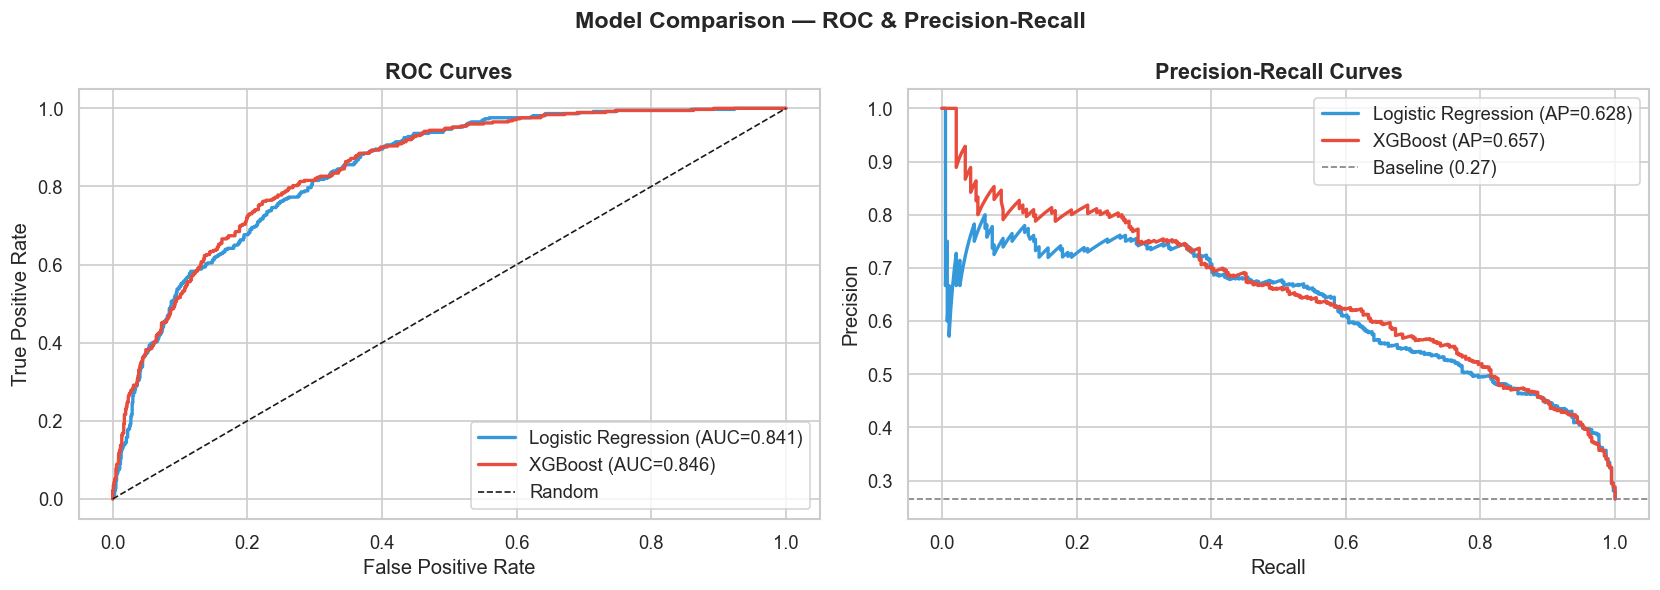

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
for name, probs, color in [
    ('Logistic Regression', lr_probs, '#3498db'),
    ('XGBoost', xgb_probs, '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend()

# Precision-Recall curves
for name, probs, color in [
    ('Logistic Regression', lr_probs, '#3498db'),
    ('XGBoost', xgb_probs, '#e74c3c')
]:
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec_curve, prec_curve, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')

axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', linewidth=1, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('Model Comparison — ROC & Precision-Recall', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/11_roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 8. Confusion Matrices

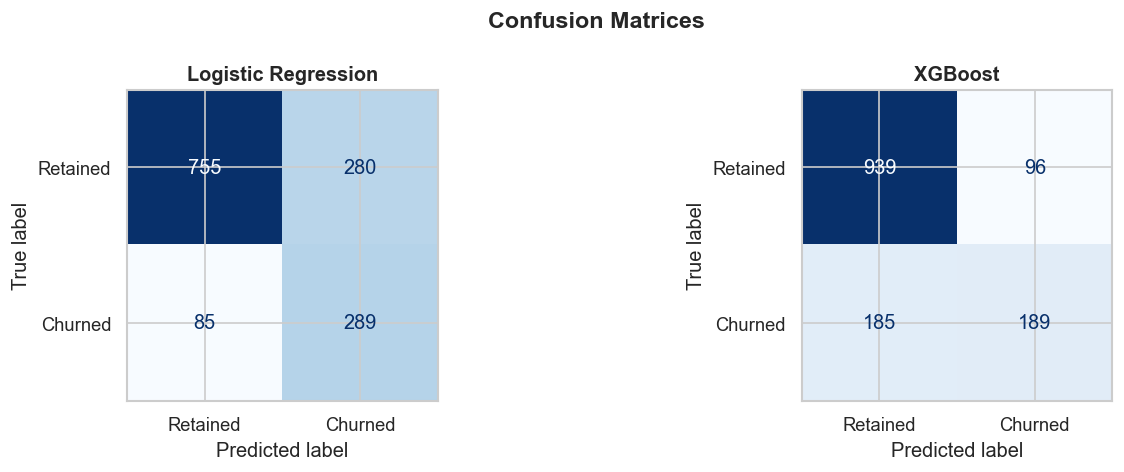

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in [
    (axes[0], lr_preds,  'Logistic Regression'),
    (axes[1], xgb_preds, 'XGBoost')
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=['Retained', 'Churned'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/12_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 9. XGBoost Feature Importance

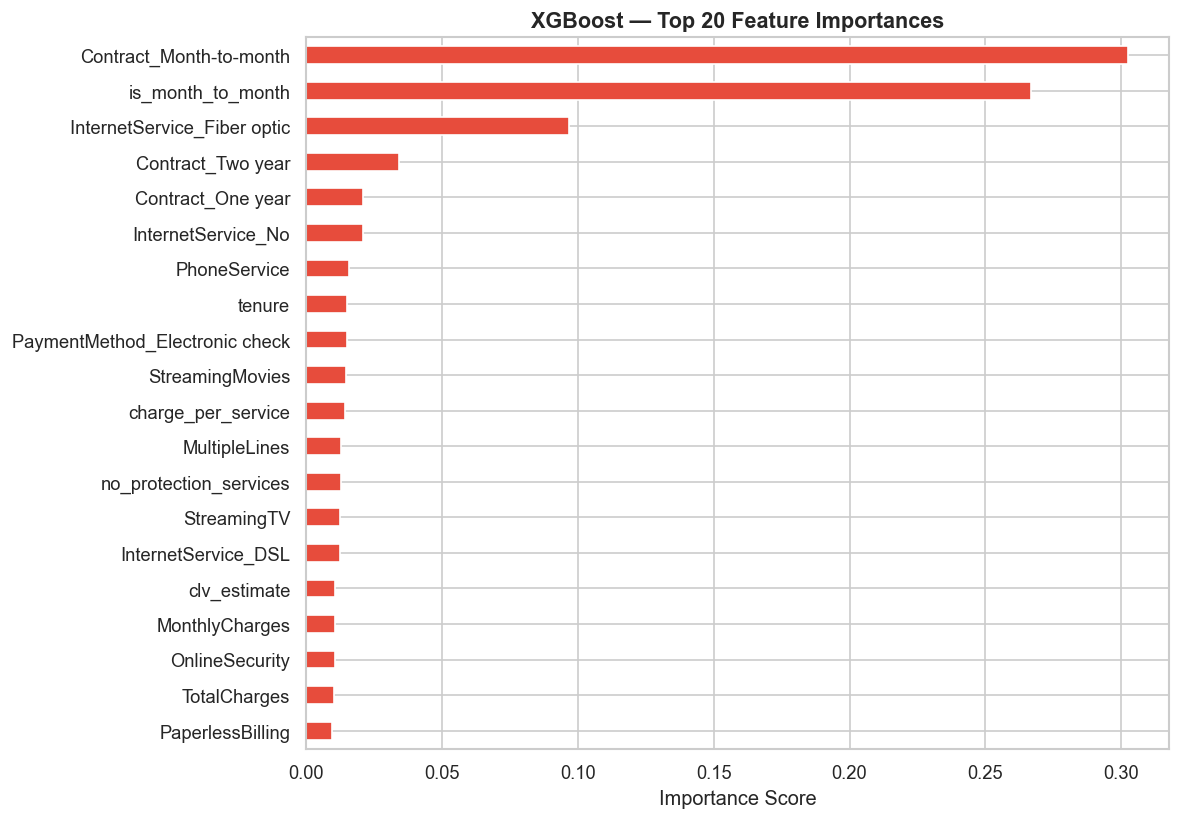

Top 5 most important features:
Contract_Month-to-month        0.302368
is_month_to_month              0.266909
InternetService_Fiber optic    0.096782
Contract_Two year              0.034112
Contract_One year              0.020926
dtype: float32


In [12]:
importances = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/figures/13_xgb_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
print(importances.tail(5).sort_values(ascending=False))

## 10. Revenue Risk Scoring

This is what separates our project from a standard churn classifier. We combine the churn probability with CLV to rank customers by *business impact*.

In [13]:
# Build risk score DataFrame on test set
results = X_test.copy()
results['actual_churn']      = y_test.values
results['churn_probability'] = xgb_probs
results['predicted_churn']   = xgb_preds

# Revenue risk = churn probability × CLV estimate
results['revenue_risk_score'] = results['churn_probability'] * results['clv_estimate']

results_sorted = results.sort_values('revenue_risk_score', ascending=False)

print('Top 10 customers by revenue risk score:')
print(results_sorted[['churn_probability', 'clv_estimate', 'revenue_risk_score', 'actual_churn']]
      .head(10)
      .round(2)
      .to_string())

print(f'\nTotal revenue at risk (predicted churners): ${results[results["predicted_churn"]==1]["revenue_risk_score"].sum():,.0f}')
print(f'Number of predicted churners: {results["predicted_churn"].sum()}')

Top 10 customers by revenue risk score:
      churn_probability  clv_estimate  revenue_risk_score  actual_churn
2860               0.50       6793.80             3411.32             0
3411               0.58       5400.70             3152.36             1
2282               0.47       6567.00             3110.85             1
6244               0.58       5348.70             3098.06             0
7023               0.45       6520.50             2934.03             0
402                0.41       6862.05             2799.04             1
1081               0.60       4547.10             2736.14             0
4264               0.56       4804.70             2674.08             0
4572               0.41       6369.00             2633.84             0
6544               0.59       4399.50             2617.33             1

Total revenue at risk (predicted churners): $140,854
Number of predicted churners: 285


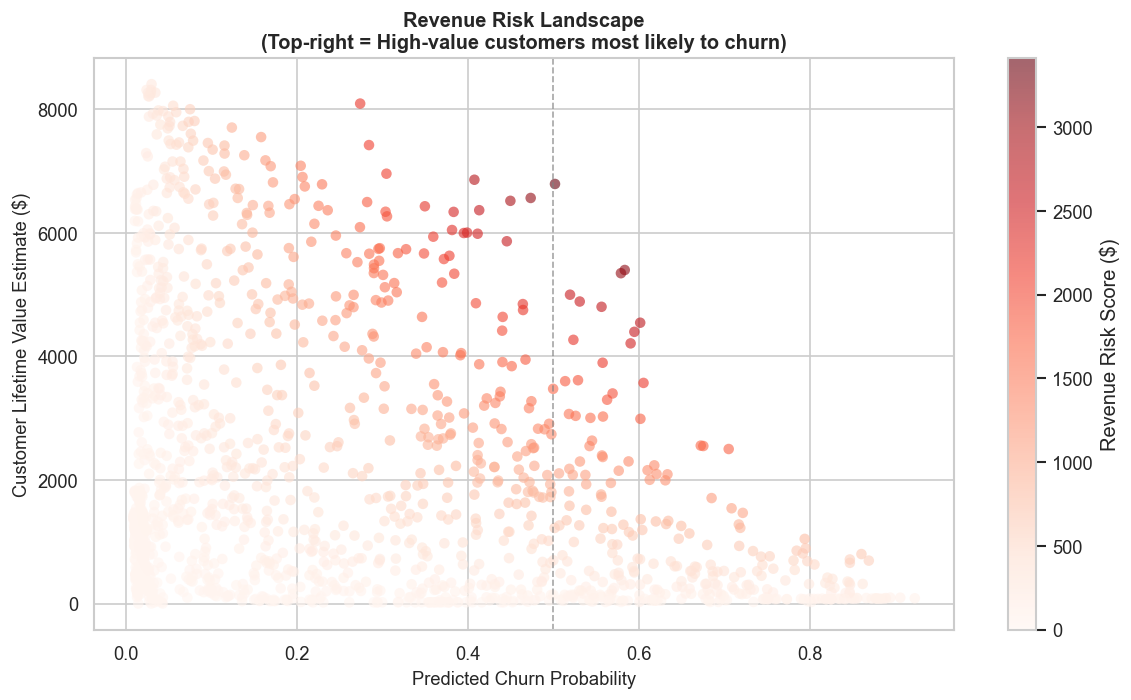

In [14]:
# Scatter: CLV vs Churn Probability (the money chart)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    results['churn_probability'],
    results['clv_estimate'],
    c=results['revenue_risk_score'],
    cmap='Reds',
    alpha=0.6,
    s=40,
    edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Revenue Risk Score ($)')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Predicted Churn Probability', fontsize=11)
ax.set_ylabel('Customer Lifetime Value Estimate ($)', fontsize=11)
ax.set_title('Revenue Risk Landscape\n(Top-right = High-value customers most likely to churn)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/14_revenue_risk_scatter.png', bbox_inches='tight')
plt.show()

## 11. Save Models & Predictions

In [15]:
# Save models
joblib.dump(lr_pipeline, '../models/logistic_regression.joblib')
joblib.dump(xgb_model,   '../models/xgboost.joblib')
print('Models saved to models/')

# Save full predictions for dashboard
# Run on ALL data (not just test set) so dashboard has full customer list
all_probs = xgb_model.predict_proba(X)[:, 1]
all_preds = xgb_model.predict(X)

predictions_df = df[['clv_estimate', 'tenure', 'MonthlyCharges']].copy()

# Add contract type back from original features
if 'Contract_Month-to-month' in df.columns:
    predictions_df['contract'] = np.where(
        df['Contract_Month-to-month'] == 1, 'Month-to-month',
        np.where(df['Contract_One year'] == 1, 'One year', 'Two year')
    )

predictions_df['churn_probability']  = all_probs
predictions_df['predicted_churn']    = all_preds
predictions_df['revenue_risk_score'] = all_probs * predictions_df['clv_estimate']
predictions_df['customer_id']        = [f'C{i:04d}' for i in range(len(predictions_df))]

predictions_df.to_csv('../data/processed/predictions.csv', index=False)
print('Predictions saved to data/processed/predictions.csv')
print(f'Shape: {predictions_df.shape}')

Models saved to models/
Predictions saved to data/processed/predictions.csv
Shape: (7043, 8)


## 12. Final Summary

| Model | AUC-ROC | F1 Score | Avg Precision |
|---|---|---|---|
| Logistic Regression | See above | See above | See above |
| XGBoost | See above | See above | See above |

**Key takeaways:**
- XGBoost outperforms logistic regression on AUC-ROC — it captures non-linear relationships between features
- Logistic regression coefficients confirm EDA findings: contract type and internet service are the biggest drivers
- Revenue risk scoring lets the business prioritize retention outreach by dollar impact, not just churn probability
- Predictions saved to `data/processed/predictions.csv` — the dashboard will now show real model scores

**Next:** Run the dashboard with real predictions using `streamlit run src/dashboard/app.py`